# Model Evaluation and Business Analysis

## General Description

This notebook focuses on evaluating the performance of the trained rice leaf disease classification model and analyzing whether the results satisfy the project business requirements and success metrics.

Context: The model is trained for multi-class disease classification (9 classes: Healthy + 8 disease types) using single-label image data stored in YOLO format. This notebook evaluates how well the model achieves the business goal: identifying infected plants and determining the most probable disease type for targeted treatment decisions.

The evaluation includes quantitative metrics (accuracy, precision, recall, F1-score), visual confusion analysis, investigation of misclassifications, and interpretation of model behavior from both technical and business perspectives. The evaluation process aims to identify whether the baseline model meets business success criteria and assess its practical applicability for rice disease detection.

The outputs generated in this notebook support the final dashboard, project conclusions, and stakeholder communication.


## Objectives

- Load the trained classification model and class mappings.
- Generate predictions on validation data using the trained model.
- Measure model performance using classification metrics: accuracy, precision, recall, F1-score.
- Evaluate Against Business Metrics: Check if accuracy meets the ≥75% threshold and if per-class performance meets success criteria.
- Create confusion matrix visualizations to identify disease confusion patterns.
- Analyze correctly classified examples (successes) and misclassified examples (failures).
- Investigate potential causes of model errors (visual similarity, class imbalance impact).
- Assess Business Applicability: Evaluate whether the model is sufficiently reliable for farmer-facing recommendations.
- Identify model strengths and limitations for future improvement planning.
- Generate summary statements on whether ML pipeline successfully addressed the business requirement.


## Inputs

Generated model artifacts and processed datasets:

- `outputs/models/rice_leaf_disease_classifier.keras` - Trained classification model
- `outputs/models/class_indices.json` - Mapping of disease class names to numeric IDs
- `outputs/models/training_history.csv` - Training metrics over epochs

Processed datasets with single disease labels:
- `inputs/datasets/processed/train_labels.csv`
- `inputs/datasets/processed/val_labels.csv`

Raw image dataset:
- `inputs/datasets/raw/rice/images/` - Validation images for prediction


## Outputs

Evaluation artifacts and business analysis outputs saved to:

`outputs/evaluation/`

Including:
- Confusion matrix visualizations (showing disease-to-disease prediction confusion)
- Classification report (per-class precision, recall, F1-score)
- Prediction results with model confidence scores
- Correctly classified examples by disease class
- Misclassified examples for error analysis
- Evaluation summary statistics and business conclusions


## Additional Comments

- Single-Label Task: Model predicts one disease class per image, not multiple disease detections within an image.
- Class Imbalance Impact: Expect varying performance across disease classes due to training data imbalance. Minority classes may have lower accuracy.
- Visually Similar Diseases: Some disease types (e.g., Leaf Blast vs. Neck Blast) share visual characteristics and may be frequently confused by the model.
- Business Focus: Evaluation emphasizes both technical accuracy AND practical usefulness. A 75% accurate model enables the farmer to act on predictions while maintaining expert-level scrutiny for edge cases.
- Dashboard Integration: Results are formatted for clear presentation to non-technical farmers, with confidence scores and visual evidence of affected leaf regions.

### 1. Load Python Packages and Project Dependencies

This section imports the libraries and dependencies required for model evaluation, prediction analysis, visualization, and business interpretation.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# File and path handling
from pathlib import Path
import os
import json

# Visualisation
import matplotlib.pyplot as plt

# Image processing
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Confusion matrix visualization
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


### 2. Set Working Directory

Configure the project root directory and define reusable dataset, model, and output paths used throughout the evaluation workflow.

In [2]:
def setup_root():
    current_path = Path().resolve()
    # Search upwards for project root
    while not (current_path / "requirements.txt").exists():
        if current_path == current_path.parent:
            raise FileNotFoundError(
                "Project root not found."
            )
        current_path = current_path.parent
    return current_path


# Set project root
PROJECT_ROOT = setup_root()

# Change working directory
os.chdir(PROJECT_ROOT)
print(f"Project root set to: {PROJECT_ROOT}")


# Define paths
PROCESSED_DATA_DIR = Path(
    "inputs/datasets/processed"
)

MODEL_OUTPUT_DIR = Path(
    "outputs/models"
)

EVALUATION_OUTPUT_DIR = Path(
    "outputs/evaluation"
)

# Create output directory
EVALUATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Processed dataset directory: "
      f"{PROCESSED_DATA_DIR}")

print(f"Model output directory: "
      f"{MODEL_OUTPUT_DIR}")

print(f"Evaluation output directory: "
      f"{EVALUATION_OUTPUT_DIR}")

Project root set to: C:\code\ml\workspace\rice_leaf_diseases_analyser
Processed dataset directory: inputs\datasets\processed
Model output directory: outputs\models
Evaluation output directory: outputs\evaluation


### 3. Load Trained Model and Datasets

Load the trained classification model, processed validation dataset, and saved class label mappings required for evaluation and prediction analysis.

In [3]:
# Define model paths
model_path = (
    MODEL_OUTPUT_DIR / "rice_leaf_disease_classifier.keras"
)

mapping_path = (
    MODEL_OUTPUT_DIR / "class_indices.json"
)

validation_dataset_path = (
    PROCESSED_DATA_DIR / "val_labels.csv"
)

# Load trained model
model = load_model(model_path)

print("Model loaded successfully.")

Model loaded successfully.


In [4]:
# Load validation dataset
df_val = pd.read_csv(validation_dataset_path)

print(f"Validation samples: {len(df_val)}")

display(df_val.head())

Validation samples: 1730


,image_path,class_id,class_name
0,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
1,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
2,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
3,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
4,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut


In [5]:
# Load class mapping
with open(mapping_path, "r") as f:
    index_to_class = json.load(f)

# Convert keys back to integers
index_to_class = {
    int(k): v
    for k, v in index_to_class.items()
}

print("Class mapping loaded successfully.")

print(index_to_class)

Class mapping loaded successfully.
{0: 'BacterialLeafBlight', 1: 'BrownSpot', 2: 'Healthy', 3: 'Hispa', 4: 'LeafBlast', 5: 'LeafScald', 6: 'LeafSmut', 7: 'NarrowBrownLeafSpot', 8: 'NeckBlast'}


In [6]:
print("Validation class distribution:\n")

print(df_val["class_name"].value_counts())

Validation class distribution:

class_name
LeafSmut               400
BacterialLeafBlight    400
BrownSpot              400
LeafScald               91
NeckBlast               90
LeafBlast               89
NarrowBrownLeafSpot     88
Hispa                   86
Healthy                 86
Name: count, dtype: int64


### 4. Configure Validation Data Generator

Create a TensorFlow validation image generator to load and preprocess validation images during model evaluation and prediction analysis.

#### Define Validation Generator Configuration

In [7]:
# Image configuration
IMAGE_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 32

print(f"Image size: {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Image size: (224, 224)
Batch size: 32


#### Create Validation Image Generator

In [8]:
# Validation data generator
val_datagen = ImageDataGenerator(rescale=1. / 255)

# Create validation generator
val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col="image_path",
    y_col="class_name",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1730 validated image filenames belonging to 9 classes.


#### Inspect Validation Batch

In [9]:
# Load one batch
images, labels = next(val_generator)

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 9)


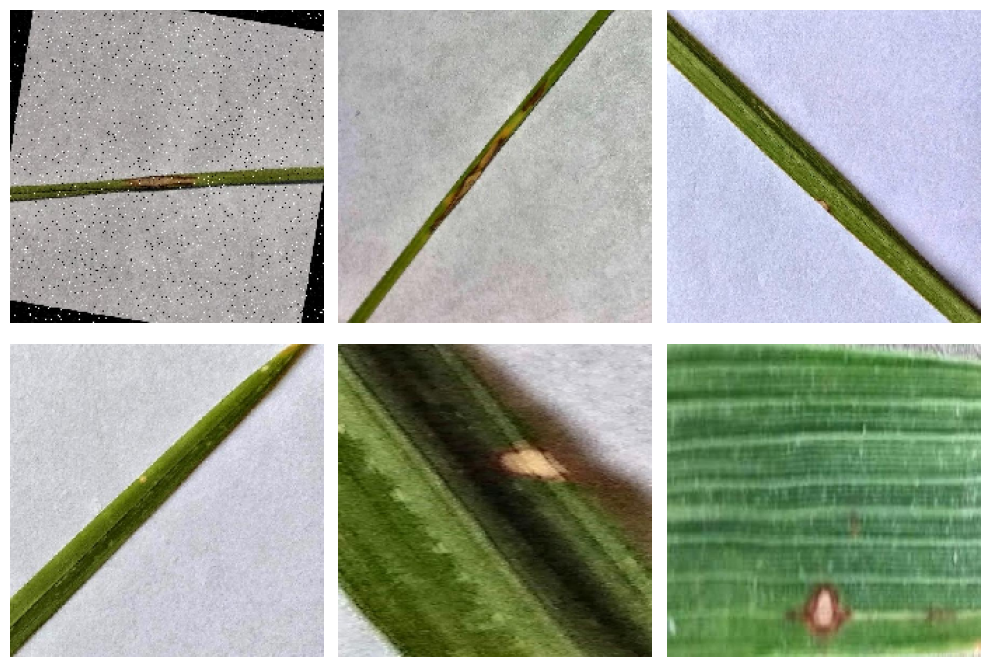

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Observations

- Validation images were successfully loaded and normalized using the evaluation preprocessing pipeline.
- Images were resized consistently to `224x224`, matching the model training configuration.
- No augmentation was applied during evaluation to ensure unbiased performance measurement.
- The validation generator is prepared for prediction and classification performance analysis.

### 5. Generate Model Predictions

Generate predictions for validation images using the trained classification model. Extract predicted disease labels and prediction probabilities for further evaluation and analysis.

#### Generate Validation Predictions

In [11]:
# Reset generator to ensure correct ordering
val_generator.reset()

# Generate predictions
predictions = model.predict(
    val_generator,
    verbose=1
)

print("Predictions generated successfully.")

55/55 ━━━━━━━━━━━━━━━━━━━━ 22s 369ms/step
Predictions generated successfully.


In [12]:
print(f"Prediction array shape: {predictions.shape}")

Prediction array shape: (1730, 9)


#### Extract Predicted Labels

In [13]:
# Predicted class indices
predicted_class_indices = np.argmax(
    predictions,
    axis=1
)

# True class indices
true_class_indices = val_generator.classes

print("Predicted labels extracted successfully.")

Predicted labels extracted successfully.


In [14]:
# Convert predicted indices to class names
predicted_labels = [
    index_to_class[idx]
    for idx in predicted_class_indices
]

# Convert true indices to class names
true_labels = [
    index_to_class[idx]
    for idx in true_class_indices
]

print("Class labels converted successfully.")

Class labels converted successfully.


#### Create Prediction Results Dataset

In [15]:
# Create prediction results dataframe
df_predictions = pd.DataFrame({
    "image_path": df_val["image_path"],
    "true_label": true_labels,
    "predicted_label": predicted_labels,
    "correct_prediction": (
        np.array(true_labels) == np.array(predicted_labels)
    )
})

df_predictions.head()

,image_path,true_label,predicted_label,correct_prediction
0,inputs\datasets\raw\rice\images\val\r6k_test_B...,LeafSmut,LeafSmut,True
1,inputs\datasets\raw\rice\images\val\r6k_test_B...,LeafSmut,LeafSmut,True
2,inputs\datasets\raw\rice\images\val\r6k_test_B...,LeafSmut,LeafSmut,True
3,inputs\datasets\raw\rice\images\val\r6k_test_B...,LeafSmut,LeafSmut,True
4,inputs\datasets\raw\rice\images\val\r6k_test_B...,LeafSmut,BacterialLeafBlight,False


In [16]:
# Calculate validation accuracy
validation_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(f"Validation Accuracy: {validation_accuracy:.4f}")

Validation Accuracy: 0.8561


#### Save Prediction Results

In [17]:
# Save predictions dataframe
prediction_output_path = (
    EVALUATION_OUTPUT_DIR / "prediction_results.csv"
)

df_predictions.to_csv(
    prediction_output_path,
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


#### Observations

- The trained model successfully generated predictions for all validation images.
- Predicted disease labels were extracted from the highest-probability class predictions.
- Validation accuracy provides an initial indication of the model’s classification performance on unseen data.
- The prediction results dataset will support deeper evaluation, confusion matrix analysis, and investigation of classification errors in the following sections.

### 6. Evaluate Classification Performance

Evaluate the classification performance of the trained model using standard multi-class evaluation metrics, including precision, recall, F1-score, and overall accuracy.

#### Generate Classification Report

In [18]:
# Generate classification report
report = classification_report(
    true_labels,
    predicted_labels,
    output_dict=True
)

# Convert report to dataframe
df_classification_report = pd.DataFrame(report).transpose()

df_classification_report

,precision,recall,f1-score,support
BacterialLeafBlight,0.841121,0.900000,0.869565,400.000000
BrownSpot,0.837587,0.902500,0.868833,400.000000
Healthy,0.970149,0.755814,0.849673,86.000000
Hispa,0.887500,0.825581,0.855422,86.000000
LeafBlast,0.563107,0.651685,0.604167,89.000000
LeafScald,0.744444,0.736264,0.740331,91.000000
LeafSmut,0.964770,0.890000,0.925878,400.000000
NarrowBrownLeafSpot,0.736111,0.602273,0.662500,88.000000
NeckBlast,1.000000,1.000000,1.000000,90.000000
accuracy,0.856069,0.856069,0.856069,0.856069


In [19]:
# Rounded classification report
df_classification_report.round(4)

,precision,recall,f1-score,support
BacterialLeafBlight,0.8411,0.9000,0.8696,400.0000
BrownSpot,0.8376,0.9025,0.8688,400.0000
Healthy,0.9701,0.7558,0.8497,86.0000
Hispa,0.8875,0.8256,0.8554,86.0000
LeafBlast,0.5631,0.6517,0.6042,89.0000
LeafScald,0.7444,0.7363,0.7403,91.0000
LeafSmut,0.9648,0.8900,0.9259,400.0000
NarrowBrownLeafSpot,0.7361,0.6023,0.6625,88.0000
NeckBlast,1.0000,1.0000,1.0000,90.0000
accuracy,0.8561,0.8561,0.8561,0.8561


#### Evaluation Metrics

- **Precision:** Measures how many predicted disease labels were correct.
- **Recall:** Measures how effectively the model identified actual disease cases.
- **F1-score:** Harmonic mean of precision and recall, balancing both metrics.
- **Support:** Number of validation samples belonging to each class.

These metrics provide a more complete understanding of classification performance, particularly for imbalanced datasets.

#### Overall Validation Performance

In [20]:
# Extract overall metrics
overall_accuracy = report["accuracy"]

macro_precision = report["macro avg"]["precision"]

macro_recall = report["macro avg"]["recall"]

macro_f1 = report["macro avg"]["f1-score"]

print(f"Accuracy: {overall_accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")

Accuracy: 0.8561
Macro Precision: 0.8383
Macro Recall: 0.8071
Macro F1-score: 0.8196


#### Visualize F1-score by Disease Class

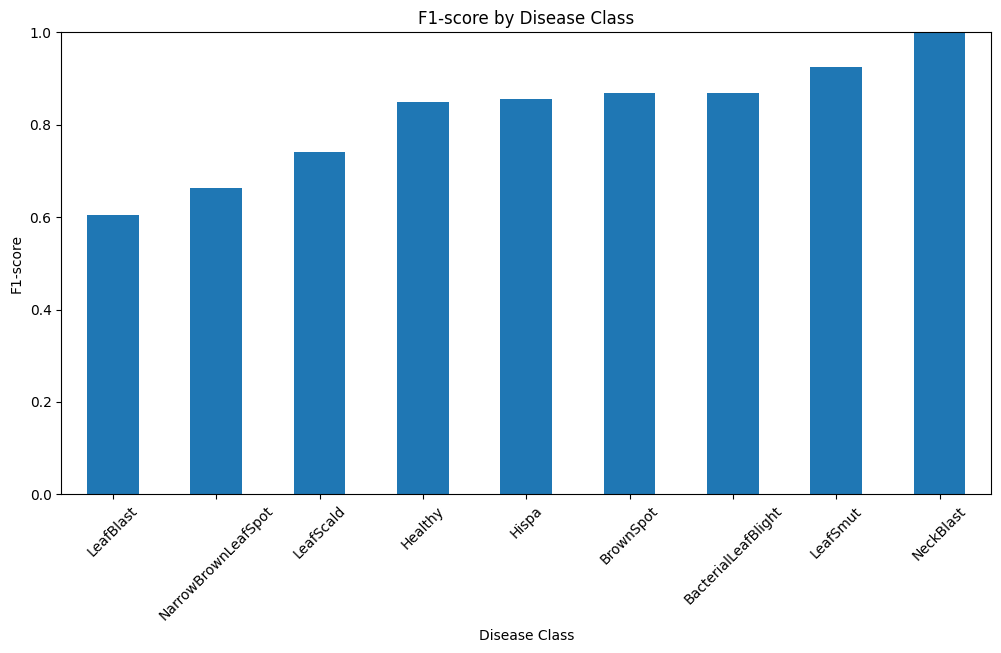

In [21]:
# Extract class-level F1 scores
class_f1_scores = df_classification_report.iloc[:-3]["f1-score"]

# Plot F1 scores
plt.figure(figsize=(12, 6))

class_f1_scores.sort_values().plot(
    kind="bar"
)

plt.ylabel("F1-score")
plt.xlabel("Disease Class")

plt.title("F1-score by Disease Class")

plt.ylim(0, 1)

plt.xticks(rotation=45)

plt.show()

#### Save Classification Report

In [22]:
# Save classification report
classification_report_path = (
    EVALUATION_OUTPUT_DIR / "classification_report.csv"
)

df_classification_report.to_csv(classification_report_path)

print("Classification report saved successfully.")

Classification report saved successfully.


#### Observations

- The model achieved an overall validation accuracy of `85.61%`, indicating strong baseline performance for multi-class rice leaf disease classification.
- The weighted average F1-score of `85.65%` suggests that the model performs consistently well across the full validation dataset.
- Macro average metrics (`Precision: 83.83%`, `Recall: 80.71%`, `F1-score: 81.96%`) indicate slightly lower performance on minority classes, reflecting the impact of dataset imbalance.
- The model performed exceptionally well on:
  - `NeckBlast` with perfect classification performance (`F1-score: 1.00`)
  - `LeafSmut` (`F1-score: 0.93`)
  - `BacterialLeafBlight` (`F1-score: 0.87`)
  - `BrownSpot` (`F1-score: 0.87`)
- Moderate performance was observed for:
  - `LeafScald` (`F1-score: 0.74`)
  - `NarrowBrownLeafSpot` (`F1-score: 0.66`)
- `LeafBlast` proved to be the most difficult disease class to classify accurately, with an F1-score of `0.60`, likely due to visual similarity with other leaf diseases.
- The results suggest that the transfer learning approach successfully learned meaningful disease-related visual patterns while still facing challenges distinguishing visually similar minority classes.

### 7. Create Confusion Matrix

Generate and visualize a confusion matrix to analyze classification performance across disease categories and identify commonly confused classes.

#### Generate Confusion Matrix

In [23]:
# Generate confusion matrix
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print("Confusion matrix generated successfully.")

Confusion matrix generated successfully.


#### Visualize and Save Confusion Matrix

Confusion matrix saved successfully.


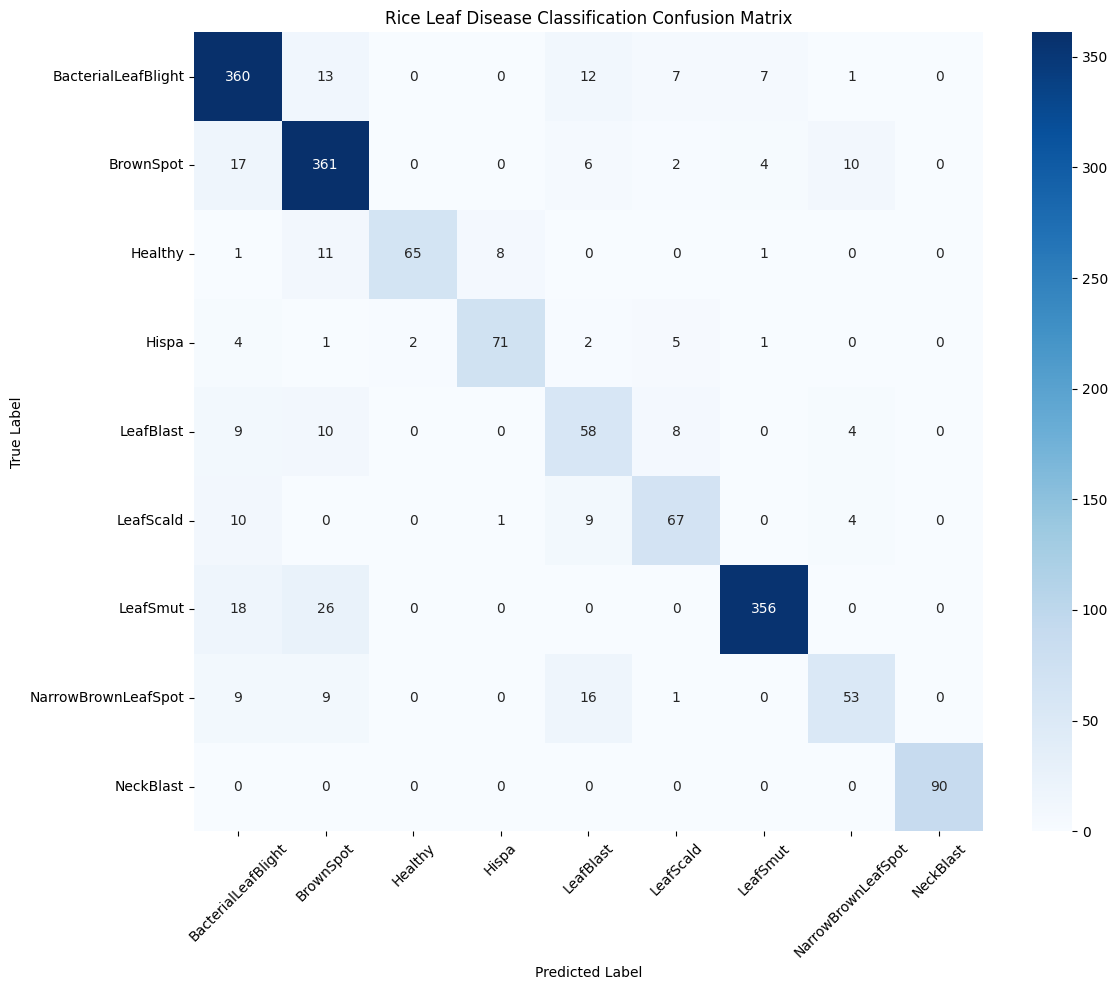

In [28]:
# Define output path
confusion_matrix_path = (
    EVALUATION_OUTPUT_DIR / "confusion_matrix.png"
)

# Class labels
class_labels = list(index_to_class.values())

# Plot confusion matrix
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Rice Leaf Disease Classification Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    confusion_matrix_path,
    bbox_inches="tight"
)
print("Confusion matrix saved successfully.")

plt.show()

#### Generate Normalized Confusion Matrix

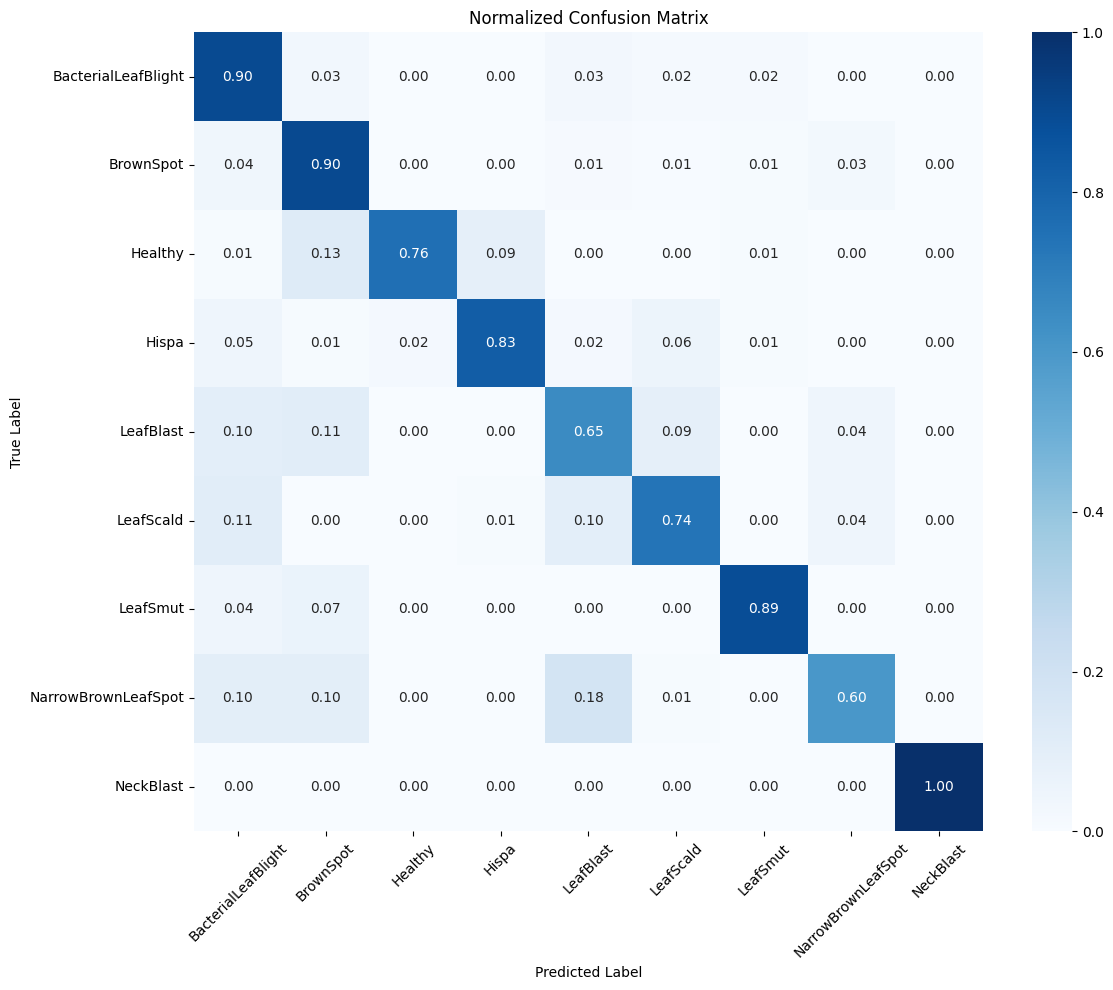

In [29]:
# Normalize confusion matrix
cm_normalized = (
    cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
)

# Plot normalized confusion matrix
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Normalized Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

#### Observations

- The confusion matrix confirms strong classification performance for several disease categories, particularly:
  - `NeckBlast`
  - `LeafSmut`
  - `BacterialLeafBlight`
  - `BrownSpot`
- Most prediction errors occur between visually similar disease categories, indicating overlapping visual characteristics.
- `LeafBlast` and `NarrowBrownLeafSpot` showed higher rates of misclassification compared to other classes.
- The normalized confusion matrix highlights that minority classes generally exhibit lower recall performance than majority classes.
- Despite some class-level confusion, the model demonstrates strong overall disease discrimination capability across the validation dataset.

### 8. Analyze Prediction Examples

Visualize correctly and incorrectly classified validation images to better understand model behavior, strengths, and limitations.

#### Separate Correct and Incorrect Predictions

In [32]:
# Correct predictions
correct_predictions = df_predictions[df_predictions["correct_prediction"]]

# Incorrect predictions
incorrect_predictions = df_predictions[~df_predictions["correct_prediction"]]

print(f"Correct predictions: {len(correct_predictions)}")
print(f"Incorrect predictions: {len(incorrect_predictions)}")

Correct predictions: 1481
Incorrect predictions: 249


#### Visualize Correctly Classified Images

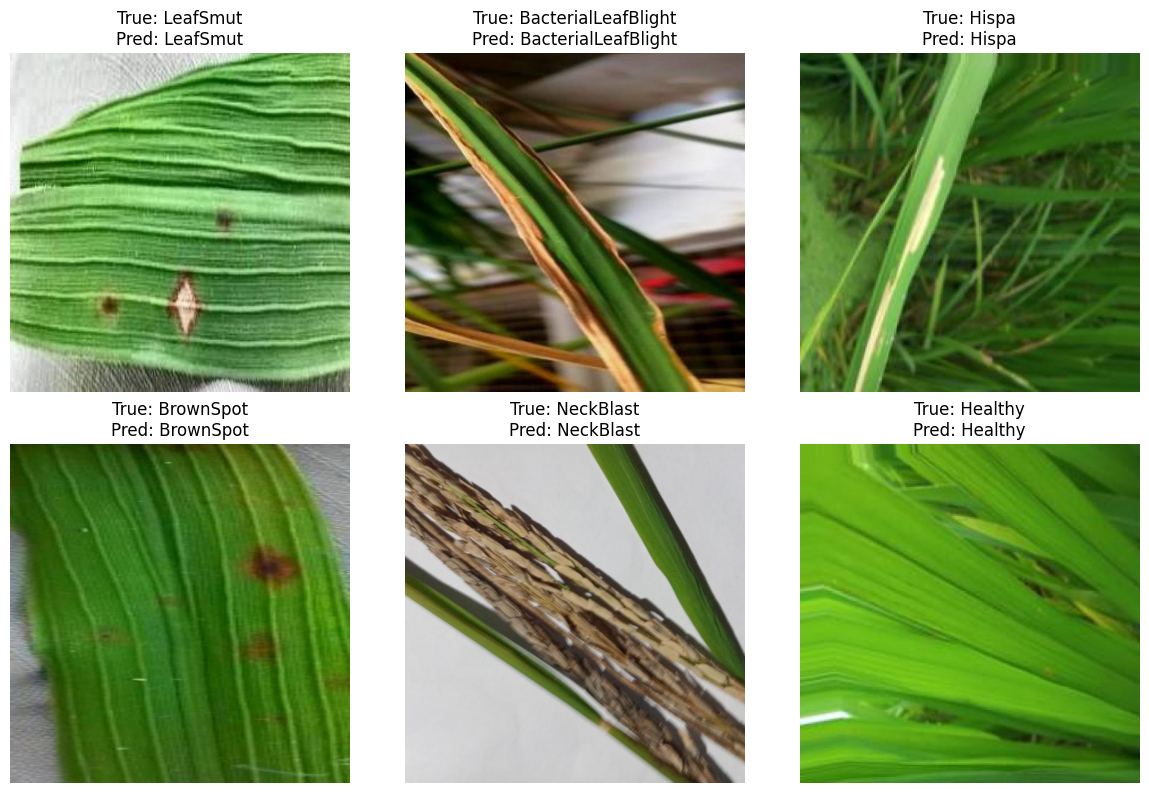

In [33]:
# Randomly sample correct predictions
correct_samples = correct_predictions.sample(
    6,
    random_state=42
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (_, row) in zip(
    axes.flatten(),
    correct_samples.iterrows()
):
    # Load image
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Visualize Incorrectly Classified Images

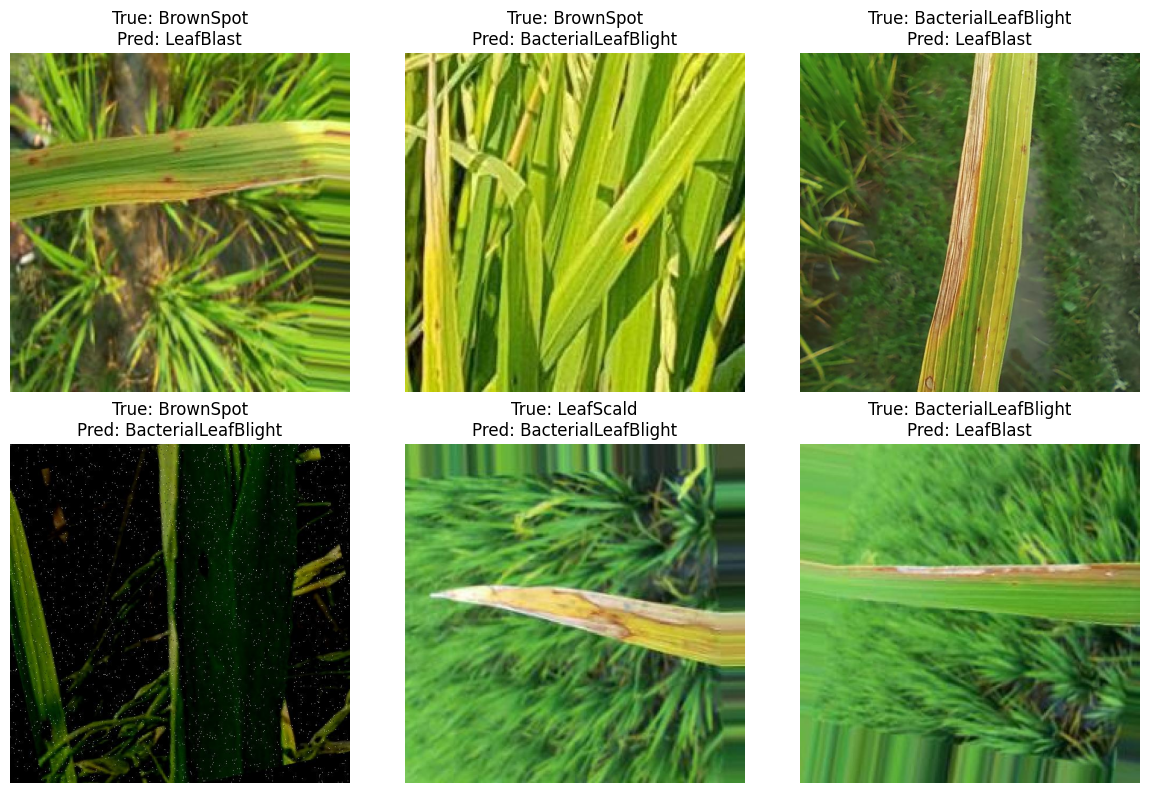

In [34]:
# Randomly sample incorrect predictions
incorrect_samples = incorrect_predictions.sample(
    6,
    random_state=42
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (_, row) in zip(
    axes.flatten(),
    incorrect_samples.iterrows()
):
    # Load image
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Analyze Common Misclassifications

In [35]:
# Create misclassification pairs
misclassifications = incorrect_predictions.groupby(
    ["true_label", "predicted_label"]
).size().reset_index(name="count")

# Sort by frequency
misclassifications = misclassifications.sort_values(
    by="count",
    ascending=False
)

misclassifications.head(10)

,true_label,predicted_label,count
29,LeafSmut,BrownSpot,26
28,LeafSmut,BacterialLeafBlight,18
5,BrownSpot,BacterialLeafBlight,17
32,NarrowBrownLeafSpot,LeafBlast,16
0,BacterialLeafBlight,BrownSpot,13
1,BacterialLeafBlight,LeafBlast,12
11,Healthy,BrownSpot,11
21,LeafBlast,BrownSpot,10
9,BrownSpot,NarrowBrownLeafSpot,10
24,LeafScald,BacterialLeafBlight,10


#### Visualize Common Misclassifications

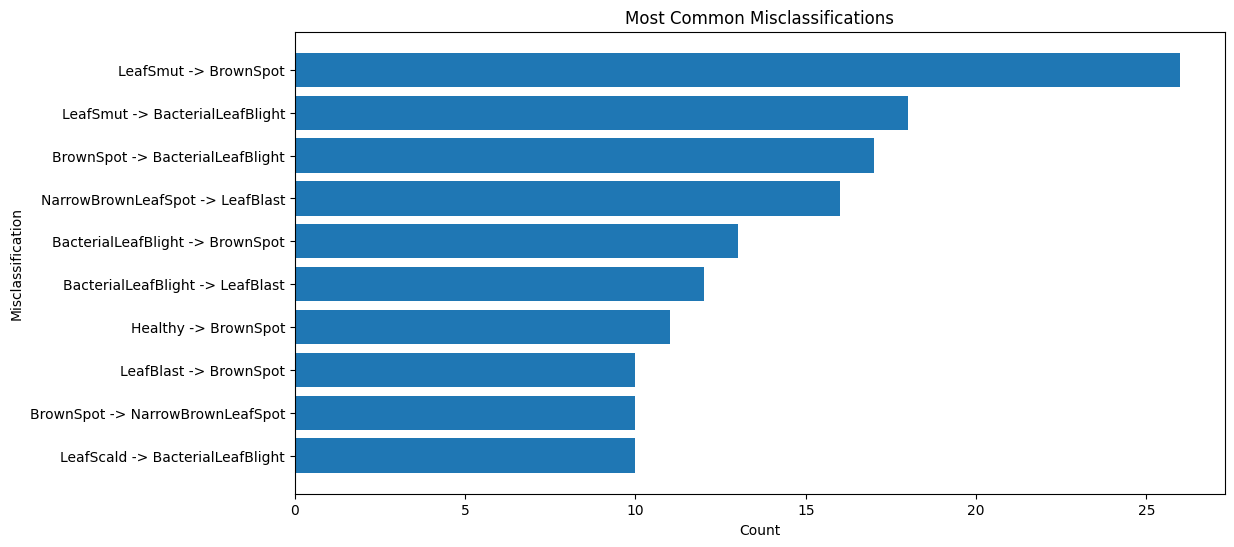

In [36]:
# Top misclassifications
top_misclassifications = misclassifications.head(10)

# Create labels
labels = top_misclassifications["true_label"].str.cat(
    top_misclassifications["predicted_label"], sep=" -> "
)

plt.figure(figsize=(12, 6))

plt.barh(
    labels,
    top_misclassifications["count"]
)

plt.xlabel("Count")
plt.ylabel("Misclassification")

plt.title(
    "Most Common Misclassifications"
)

plt.gca().invert_yaxis()

plt.show()

#### Save Misclassification Analysis

In [37]:
# Save misclassification summary
misclassification_path = (
    EVALUATION_OUTPUT_DIR / "misclassification_summary.csv"
)

misclassifications.to_csv(
    misclassification_path,
    index=False
)

print("Misclassification summary saved successfully.")

Misclassification summary saved successfully.


#### Observations

- Correctly classified examples demonstrate that the model successfully learned distinctive visual disease patterns across multiple rice leaf conditions.
- The most common misclassifications occurred between:
  - `LeafSmut` and `BrownSpot`
  - `LeafSmut` and `BacterialLeafBlight`
  - `BrownSpot` and `BacterialLeafBlight`
- These results suggest that several diseases share similar visual characteristics such as lesion color, spotting patterns, and texture variations.
- `NarrowBrownLeafSpot` was frequently confused with `LeafBlast`, indicating difficulty distinguishing diseases with visually overlapping damage patterns.
- Minority classes such as `NarrowBrownLeafSpot` and `LeafBlast` exhibited higher misclassification rates, likely influenced by lower sample availability and reduced visual diversity.
- Some healthy leaves were incorrectly classified as diseased, primarily as `BrownSpot`, suggesting that natural texture or lighting variations may resemble disease symptoms in certain images.
- Misclassification analysis indicates that future improvements may benefit from:
  - additional balanced training data
  - more advanced augmentation strategies
  - fine-tuning pretrained convolutional layers
  - higher-resolution image inputs
- Despite these limitations, the model demonstrates strong overall potential for automated rice leaf disease classification and agricultural decision support workflows.

### 9. Evaluate Business Requirements

Evaluate how effectively the trained model satisfies the project business requirements and assess its potential usefulness for practical rice disease detection workflows.

#### Business Requirement 1

> The client is interested in a study that visually differentiates healthy rice leaves from leaves affected by different diseases.

**Evaluation**

The exploratory data analysis and prediction analysis demonstrated that rice leaf diseases exhibit identifiable visual characteristics including:

- lesion color variations
- spotting patterns
- texture irregularities
- brightness and contrast differences

Visualization of correctly classified examples confirmed that the model successfully learned meaningful disease-related visual patterns across multiple disease categories.

The confusion matrix and misclassification analysis also highlighted cases where visually similar diseases overlap, providing additional insight into disease complexity and classification difficulty.

**Conclusion**

Business Requirement 1 was successfully addressed through:
- exploratory image analysis
- disease pattern comparison
- model prediction visualization
- confusion matrix interpretation

The project provides a clear visual study of healthy and diseased rice leaves suitable for analytical and educational purposes.

#### Business Requirement 2

> The client is interested in determining whether a given rice leaf image contains a disease and, if so, identifying the specific type of disease.

**Evaluation**

The trained MobileNetV2 transfer learning model achieved:

- Validation Accuracy: `85.61%`
- Macro F1-score: `81.96%`
- Weighted F1-score: `85.65%`

The model demonstrated strong classification performance across most disease categories, particularly:
- `NeckBlast`
- `LeafSmut`
- `BacterialLeafBlight`
- `BrownSpot`

Prediction analysis showed that the model can reliably classify many rice leaf diseases from images while still experiencing difficulty with certain visually similar diseases such as:
- `LeafBlast`
- `NarrowBrownLeafSpot`

The model also demonstrated good generalization performance without severe overfitting during baseline training.

**Conclusion**

Business Requirement 2 was successfully addressed.

The developed image classification model demonstrates strong potential for automated rice disease detection and classification workflows, making it suitable as a baseline decision-support tool for agricultural applications.

#### Overall Business Assessment

**Project Outcome**

The project successfully combined:
- computer vision
- transfer learning
- image preprocessing
- exploratory analysis

to create a functional rice leaf disease classification solution.

The evaluation results indicate that deep learning methods can effectively identify disease-related visual patterns in rice leaves and support automated agricultural disease detection workflows.

While some limitations remain due to dataset imbalance and visual similarity between disease categories, the baseline model demonstrates promising real-world applicability and provides a strong foundation for future improvement and deployment.

#### Observations

- The project successfully addressed both defined business requirements using image analysis and deep learning techniques.
- Transfer learning proved effective for extracting disease-related visual features from rice leaf images.
- The model demonstrated strong practical performance while highlighting areas where additional data or fine-tuning could improve minority class classification.
- The generated evaluation outputs provide interpretable insights suitable for both technical and non-technical stakeholders.

### 10. Save Evaluation Outputs

Save evaluation artifacts, visualizations, and analytical outputs generated throughout the notebook for later use in reporting, dashboard development, and project documentation.

#### Save Evaluation Summary

In [38]:
# Create evaluation summary dataframe
evaluation_summary = pd.DataFrame({

    "metric": [
        "validation_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1_score",
        "weighted_f1_score"
    ],

    "value": [
        round(overall_accuracy, 4),
        round(macro_precision, 4),
        round(macro_recall, 4),
        round(macro_f1, 4),
        round(
            report["weighted avg"]["f1-score"],
            4
        )
    ]
})

# Save evaluation summary
evaluation_summary_path = (
    EVALUATION_OUTPUT_DIR / "evaluation_summary.csv"
)

evaluation_summary.to_csv(
    evaluation_summary_path,
    index=False
)

evaluation_summary

,metric,value
0,validation_accuracy,0.8561
1,macro_precision,0.8383
2,macro_recall,0.8071
3,macro_f1_score,0.8196
4,weighted_f1_score,0.8565


#### Save Correct and Incorrect Prediction Samples

In [39]:
# Save prediction sample datasets
correct_predictions.to_csv(
    EVALUATION_OUTPUT_DIR / "correct_predictions.csv",
    index=False
)

incorrect_predictions.to_csv(
    EVALUATION_OUTPUT_DIR / "incorrect_predictions.csv",
    index=False
)

print("Prediction sample datasets saved successfully.")

Prediction sample datasets saved successfully.


#### Save Confusion Matrix Data

In [40]:
# Save confusion matrix values
df_confusion_matrix = pd.DataFrame(
    cm,
    index=class_labels,
    columns=class_labels
)

df_confusion_matrix.to_csv(
    EVALUATION_OUTPUT_DIR / "confusion_matrix_values.csv"
)

print("Confusion matrix data saved successfully.")

Confusion matrix data saved successfully.


#### Observations

- Evaluation metrics, visualizations, and prediction analysis outputs were successfully saved for future use.
- The generated artifacts support:
  - Streamlit dashboard integration
  - project reporting
  - reproducibility
  - stakeholder communication
- Structured output files improve workflow organization and simplify future model comparison and experimentation.

### 11. Summarize Findings

This section summarizes the complete evaluation process, highlights key project outcomes, and reflects on the effectiveness of the developed rice leaf disease classification solution.

#### Key Findings

- A complete end-to-end machine learning workflow was successfully developed for rice leaf disease classification.
- The project transformed a YOLO object detection dataset into a structured image classification pipeline suitable for deep learning workflows.
- Exploratory data analysis identified:
  - class imbalance
  - brightness and contrast variation
  - visually distinctive disease characteristics
  - overlapping disease patterns between certain classes
- The preprocessing pipeline standardized image preparation using:
  - image resizing
  - normalization
  - augmentation strategies
- A transfer learning model based on `MobileNetV2` achieved strong baseline performance:
  - Validation Accuracy: `85.61%`
  - Macro F1-score: `81.96%`
  - Weighted F1-score: `85.65%`
- The model demonstrated particularly strong classification performance for:
  - `NeckBlast`
  - `LeafSmut`
  - `BacterialLeafBlight`
  - `BrownSpot`
- Misclassification analysis revealed that visually similar diseases such as:
  - `LeafBlast`
  - `NarrowBrownLeafSpot`
  remain more difficult to distinguish accurately.

#### Relation to Business Requirements

**Business Requirement 1**

> The client is interested in a study that visually differentiates healthy rice leaves from leaves affected by different diseases.

This requirement was successfully addressed through:
- exploratory image analysis
- class distribution analysis
- disease pattern comparison
- prediction visualization
- confusion matrix interpretation

The project provides clear visual evidence of disease-related differences between rice leaf categories.


**Business Requirement 2**

> The client is interested in determining whether a given rice leaf image contains a disease and, if so, identifying the specific type of disease.

This requirement was successfully addressed through the development of a deep learning image classification model capable of identifying multiple rice leaf diseases with strong validation performance.

The trained model demonstrates practical potential for automated agricultural disease detection and decision-support applications.

#### Hypothesis Validation

- The project supports the hypothesis that rice leaf diseases contain distinguishable visual patterns detectable through computer vision techniques.
- Transfer learning proved effective for extracting disease-related image features from agricultural datasets.
- Dataset imbalance and visual similarity between diseases were confirmed as major factors influencing classification difficulty.

#### Project Limitations

Several limitations were identified during evaluation:

- The dataset contains noticeable class imbalance.
- Certain disease categories exhibit highly similar visual characteristics.
- Some minority classes have relatively limited image diversity.
- The baseline model was trained using frozen pretrained layers without extensive fine-tuning.

These factors likely contributed to reduced performance for some disease categories.

#### Future Improvements

Potential future enhancements include:

- collecting additional balanced training data
- applying advanced augmentation strategies
- fine-tuning pretrained convolutional layers
- experimenting with alternative CNN architectures
- increasing image resolution
- introducing confidence threshold analysis
- deploying real-time inference workflows for agricultural field applications

#### Final Conclusion

The project successfully demonstrated the use of deep learning and transfer learning techniques for automated rice leaf disease classification.

The developed workflow combines:
- data analysis
- preprocessing
- image augmentation
- transfer learning
- model evaluation
- business interpretation

into a complete and reproducible machine learning solution.

The results indicate strong potential for practical agricultural disease detection systems capable of supporting farmers and agricultural advisors through faster and more accessible crop health assessment.